# v1 Fantasy Football Draft Projection Model — Deliverable

Per CONTEXT.md/PRD (#1): a Projection per Veteran, expressed as a **PPG Projection** (P10/P50/P90
quantiles) and a **Games-Played Estimate**, combined into a **full Projection**. This notebook is the
v1 deliverable per ADR-0008: a CSV/dataframe of Projections plus this visualization + backtest report.
No API layer (that's v1.1, per ADR-0008).

In [1]:
import json

import matplotlib.pyplot as plt
import pandas as pd

pd.set_option("display.max_columns", None)
projections = pd.read_csv("../output/v1_projections.csv")
with open("../output/backtest_report.json") as f:
    backtest_report = json.load(f)

projections.shape

(348, 48)

## Final Projections

All four positions' full Projections (train through 2023, target season 2024), combined into one
dataframe — the CSV deliverable itself. `full_projection_p50` is the season-total point estimate
(`fantasy_points_p50 * games_played_estimate`); `full_projection_p10`/`full_projection_p90` are its
boom/bust range.

In [2]:
projections.groupby("position").size().rename("players_projected")

position
QB     53
RB     84
TE     70
WR    141
Name: players_projected, dtype: int64

In [3]:
key_columns = [
    "position", "player_name", "target_season", "games_played_estimate",
    "fantasy_points_p10", "fantasy_points_p50", "fantasy_points_p90",
    "full_projection_p10", "full_projection_p50", "full_projection_p90",
]
projections[key_columns].sort_values(
    ["position", "full_projection_p50"], ascending=[True, False]
).groupby("position").head(5)

,position,player_name,target_season,games_played_estimate,fantasy_points_p10,fantasy_points_p50,fantasy_points_p90,full_projection_p10,full_projection_p50,full_projection_p90
48,QB,Zach Wilson,2024,11.857143,3.831380,13.158830,27.488373,45.429216,156.026123,325.933569
46,QB,Trevor Lawrence,2024,11.857143,5.601861,12.463707,29.437491,66.422072,147.783951,349.044535
51,QB,Kenny Pickett,2024,11.857143,3.545482,10.608891,20.767917,42.039286,125.791135,246.248162
30,QB,Lamar Jackson,2024,5.555556,7.025732,22.260880,37.148583,39.031847,123.671555,206.381015
16,QB,Dak Prescott,2024,6.875940,6.201504,17.476313,31.760102,42.641168,120.166078,218.380552
58,RB,Christian McCaffrey,2024,8.342488,3.592916,14.542284,40.508063,29.973857,121.318829,337.938023
119,RB,Isiah Pacheco,2024,10.055556,2.028315,9.382196,33.357183,20.395836,94.343192,335.425011
66,RB,Joe Mixon,2024,8.342488,2.472773,11.089133,27.388946,20.629079,92.510956,228.491948
79,RB,Saquon Barkley,2024,8.342488,3.335405,10.966469,27.726810,27.825579,91.487635,231.310580
129,RB,Kyren Williams,2024,6.613982,2.138985,13.071900,33.021018,14.147209,86.457311,218.400413


## Boom/Bust Ranges (P10/P50/P90)

Top 12 players per position by `full_projection_p50`, with the P10-P90 range as an error bar — the
"boom/bust" spread the PRD asks for, not a single collapsed number (per CONTEXT.md's `Projection`
terminology).

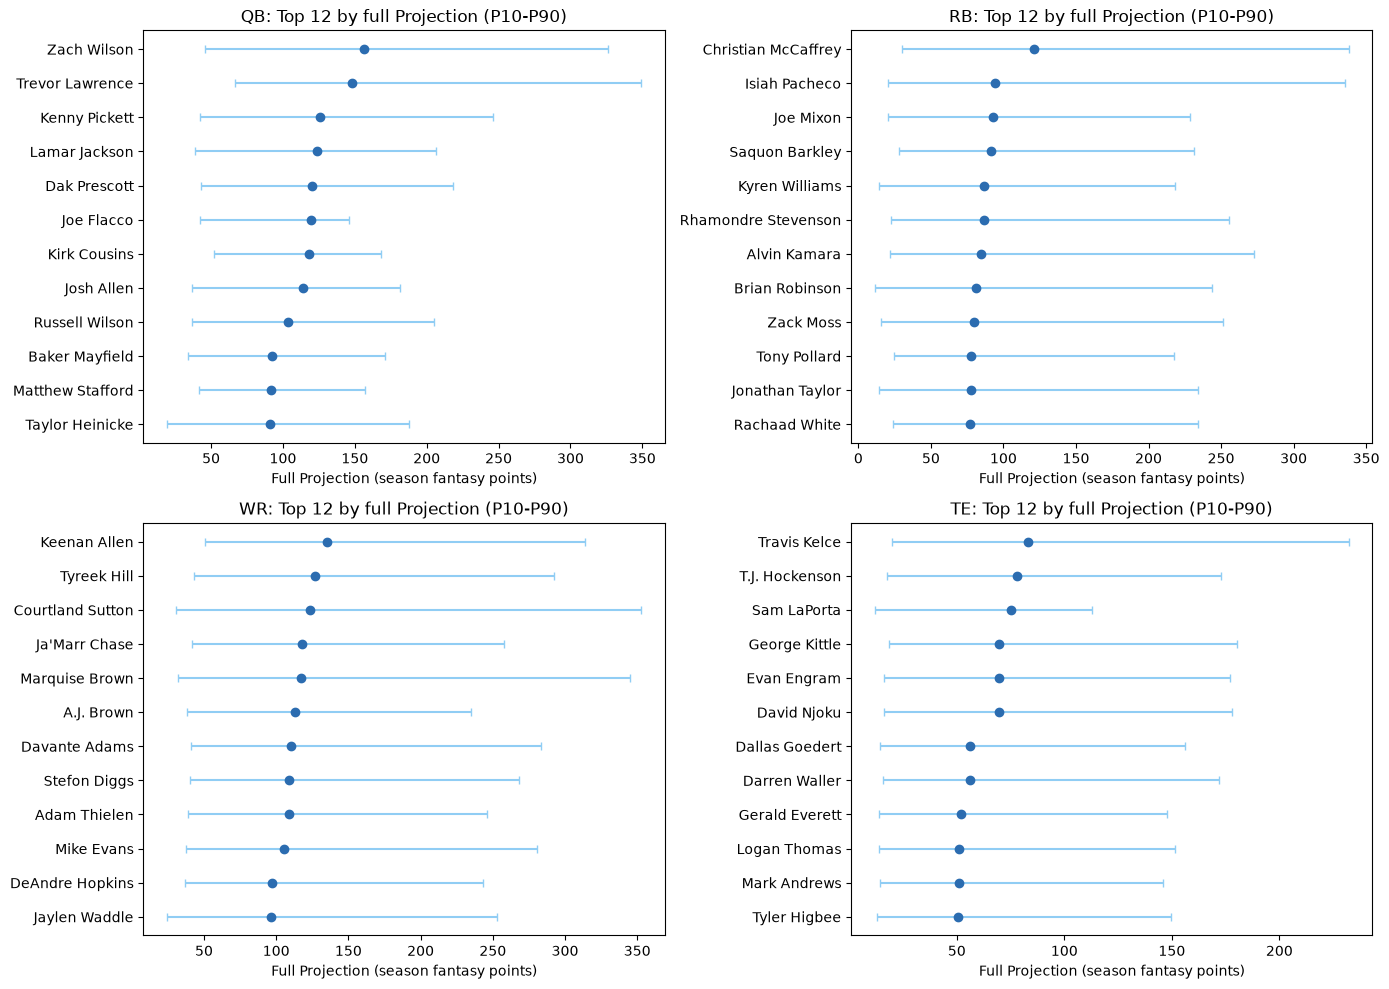

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
positions = ["QB", "RB", "WR", "TE"]

for ax, position in zip(axes.flat, positions):
    top = (
        projections.loc[projections["position"] == position]
        .nlargest(12, "full_projection_p50")
        .sort_values("full_projection_p50")
    )
    y = range(len(top))
    lower_err = top["full_projection_p50"] - top["full_projection_p10"]
    upper_err = top["full_projection_p90"] - top["full_projection_p50"]
    ax.errorbar(
        top["full_projection_p50"], y,
        xerr=[lower_err, upper_err],
        fmt="o", capsize=3, color="#2b6cb0", ecolor="#90cdf4",
    )
    ax.set_yticks(list(y))
    ax.set_yticklabels(top["player_name"])
    ax.set_title(f"{position}: Top 12 by full Projection (P10-P90)")
    ax.set_xlabel("Full Projection (season fantasy points)")

fig.tight_layout()
fig.savefig("../output/boom_bust_ranges.png", dpi=110)
plt.show()

## Walk-Forward Backtest Report

Per position, the Walk-Forward Backtest (seasons 2018-2023, expanding window, 3 splits predicting
2021/2022/2023) compares:

- **Model MAE** vs. **naive-baseline MAE** — mean absolute error of `full_projection_p50` (and the
  naive trailing-average baseline scored + combined with the same Games-Played Estimate) against
  `actual_fantasy_points` (real full-season totals, survivorship-bias-safe per issue #6 — players
  who got hurt and never returned appear with a real zero, not a dropped row).
- **Model Spearman ρ** vs. **ADP Spearman ρ** — how well each ranking (the model's `full_projection_p50`,
  or `-adp` since a lower ADP means an earlier/better expected pick) correlates with the actual
  finish-order ranking (`actual_fantasy_points`). ADP coverage is smaller (`n_with_adp`) since
  Fantasy Football Calculator's free API only covers 2020-2024, and only the subset of backtest rows
  crosswalked to a real name+position match.

In [5]:
report_df = pd.DataFrame(backtest_report).T
report_df.index.name = "position"
report_df[["n", "n_with_adp", "model_mae", "naive_mae", "model_spearman_vs_actual", "adp_spearman_vs_actual"]]

,n,n_with_adp,model_mae,naive_mae,model_spearman_vs_actual,adp_spearman_vs_actual
position,,,,,,
QB,148.0,20.0,93.892235,91.964388,0.504660,0.476692
RB,259.0,41.0,60.512669,57.230331,0.610264,0.357840
WR,424.0,54.0,58.466382,59.536449,0.648233,0.715699
TE,201.0,15.0,44.326910,39.497062,0.662849,0.485714


### Reading the comparison

- **Model vs. naive baseline (MAE, lower is better)**: the LightGBM model beats the naive
  trailing-average baseline on points error for **WR only**. For QB, RB, and TE, the naive baseline's
  MAE is lower. This is an honest, somewhat humbling result for v1 — the trained model's raw-stat
  quantile predictions aren't yet clearly outperforming "assume this season looks like the trailing
  average" for three of the four positions.
- **Model vs. ADP Benchmark (Spearman ρ, higher is better)**: the model's ranking correlates with
  actual finish-order better than ADP for **QB, RB, and TE**; ADP's crowd consensus wins for **WR**.
  So the model does show real signal against the "beat the crowd" bar (ADR-0007) for most positions,
  even where it doesn't beat the naive baseline on raw point error — ranking players well and
  predicting their exact point total are different skills, and this run shows the model is
  comparatively better at the former.
- **Net read for v1**: the model is not a clean, uniform win over both comparators across all four
  positions. It beats ADP on rank for 3/4 positions but only beats the naive baseline on points error
  for 1/4. This is useful, credible signal for a v1 model, not a finished product — a natural
  candidate area for v1.1/v2 iteration (feature work, per-position tuning) rather than a reason to
  ship something that claims to already beat every naive comparator.

## LightGBM vs. TabFM — the v1 Modeling-Approach Decision

Per ADR-0009 and issue #8: a TabFM (TabPFN-style pretrained tabular foundation model) backend was
built (`ff_model/tabfm_model.py`) as a capability alongside LightGBM, sharing the same
train/predict/quantile-output shape so the two could be swapped and compared apples-to-apples.

**The comparison never ran at production scale.** TabPFN enforces a hard 10,000-row training cap;
this pipeline's expanding-window training set (all seasons through `train_through_season`, per
position) exceeds that cap well before the backtest's later splits. Subsampling down to fit the cap
would compare LightGBM-on-full-data against TabFM-on-a-fraction-of-the-data — not a fair test, and
worse than not testing at all.

**Decision, per ADR-0009's own rule ("TabFM only replaces LightGBM if it clearly wins")**: TabFM does
not clearly win, because it was never run at a comparable scale to make that case. **LightGBM is the
v1 modeling approach for all four positions.** TabFM is documented as a v1 dead end, not deleted —
`tabfm_model.py` and its tests remain in the codebase as a working capability, in case a future
subsampling-based or TabPFN-version-upgrade approach makes a real comparison feasible.

## Related v2-Trigger Findings

- **Depth-Chart Competition Feature** (issue #5): backtested with vs. without on RB; negligible MAE
  difference (60.51 vs. 60.45) at this sample size (3 splits). Feature stays in the model; not shown
  to move the needle yet.
- **Injury-report volume vs. games played** (issue #9): weak, confounded correlation
  (`docs/research/injuries-games-played-correlation.md`) — doesn't trigger a v2 games-played submodel.
  v1's heuristic Games-Played Estimate stands.